In [4]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#read csv file
df = pd.read_csv("Housing.CSV.csv")

In [10]:
#display the first ten roles
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [11]:
#check the size of the data set
df.shape

(545, 13)

In [12]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [20]:
missing_values = df.isnull().sum()
print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [15]:
 #DATA  CLEANING
#Checking for mikssing value
missing_values = df.isnull().sum()
print(missing_values)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [25]:
#calculating the percentage of missing value
missing_percentage =(df.isnull().sum() / len(df)) * 100
print(missing_percentage)


price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64


In [26]:
# Create a summary table showing the number and percentage of missing values.
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

# Display the summary table.
print(missing_summary)

                  Missing Values  Percentage (%)
price                          0             0.0
area                           0             0.0
bedrooms                       0             0.0
bathrooms                      0             0.0
stories                        0             0.0
mainroad                       0             0.0
guestroom                      0             0.0
basement                       0             0.0
hotwaterheating                0             0.0
airconditioning                0             0.0
parking                        0             0.0
prefarea                       0             0.0
furnishingstatus               0             0.0


In [27]:
# Result:
# All columns have 0 missing values (0.0%).
# This means the dataset is complete and no missing value treatment is required.

In [28]:
#checking for duplicate
duplicate_count = df.duplicated().sum()
print( "Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


In [29]:
# Remove duplicate rows from the dataset.
# Since no duplicates were found, this will not change the dataset.

df = df.drop_duplicates()

In [30]:
# Check again to confirm there are no duplicate rows.

duplicate_count = df.duplicated().sum()

print("Duplicate rows after cleaning:", duplicate_count)

Duplicate rows after cleaning: 0


In [31]:
# Calculate the first quartile (25th percentile) for house prices.
Q1 = df["price"].quantile(0.25)

# Calculate the third quartile (75th percentile) for house prices.
Q3 = df["price"].quantile(0.75)

# Calculate the Interquartile Range (IQR).
IQR = Q3 - Q1

# Calculate the lower boundary for detecting outliers.
lower_limit = Q1 - 1.5 * IQR

# Calculate the upper boundary for detecting outliers.
upper_limit = Q3 + 1.5 * IQR

# Select all rows where the house price is below the lower limit
# or above the upper limit.
price_outliers = df[(df["price"] < lower_limit) | (df["price"] > upper_limit)]

# Display the number of outliers found.
print("Number of price outliers:", len(price_outliers))

# Display the outlier rows.
price_outliers

Number of price outliers: 15


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [35]:
# Calculate the first quartile (25th percentile) for the area column.
Q1 = df["area"].quantile(0.25)

# Calculate the third quartile (75th percentile) for the area column.
Q3 = df["area"].quantile(0.75)

# Calculate the Interquartile Range (IQR).
IQR = Q3 - Q1

# Calculate the lower limit for detecting outliers.
lower_limit = Q1 - 1.5 * IQR

# Calculate the upper limit for detecting outliers.
upper_limit = Q3 + 1.5 * IQR

# Find all rows where the area is below the lower limit
# or above the upper limit.
area_outliers = df[(df["area"] < lower_limit) | (df["area"] > upper_limit)]

# Display the number of outliers found.
print("Number of area outliers:", len(area_outliers))

# Display the rows identified as outliers.
area_outliers

Number of area outliers: 12


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
56,7343000,11440,4,1,2,yes,no,yes,no,no,1,yes,semi-furnished
64,7000000,11175,3,1,1,yes,no,yes,no,yes,1,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
69,6790000,12090,4,2,2,yes,no,no,no,no,2,yes,furnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
129,5873000,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished
186,5110000,11410,2,1,2,yes,no,no,no,no,0,yes,furnished
191,5040000,10700,3,1,2,yes,yes,yes,no,no,0,no,semi-furnished


In [36]:
# Result Interpretation:
# The IQR method identified 15 outliers in the price column
# and 12 outliers in the area column.
# These outliers were not removed because they may represent
# genuine high-priced or unusually large houses rather than data entry errors.
# Keeping these records preserves the integrity of the dataset for analysis.

In [37]:
# Display all unique values in the guestroom column.
print(df["guestroom"].unique())

['no' 'yes']


In [38]:
# Display all unique values in the basement column.
print(df["basement"].unique())

['no' 'yes']


In [39]:
# Display all unique values in the hotwaterheating column.
print(df["hotwaterheating"].unique())

['no' 'yes']


In [40]:
# Display all unique values in the airconditioning column.
print(df["airconditioning"].unique())

['yes' 'no']


In [41]:
# Display all unique values in the prefarea column.
print(df["prefarea"].unique())

['yes' 'no']


In [42]:
# Display all unique values in the furnishingstatus column.
print(df["furnishingstatus"].unique())

['furnished' 'semi-furnished' 'unfurnished']


In [43]:
#The dataset was assessed for common data quality issues, including missing values, duplicate records, outliers, and inconsistent categorical values. No missing values or duplicate rows were found, indicating that the dataset is complete and free from duplicate records. The IQR method identified 15 outliers in the price column and 12 outliers in the area column. These outliers were retained because they likely represent genuine high-priced or large properties rather than data entry errors. Overall, the dataset is clean and suitable for exploratory data analysis.

In [44]:
# Calculate the average (mean) house price.
# mean() adds all house prices together and divides by the number of houses.
average_price = df["price"].mean()

# Calculate the median house price.
# median() returns the middle value after sorting all house prices.
median_price = df["price"].median()

# Find the highest house price.
# max() returns the largest value in the column.
maximum_price = df["price"].max()

# Display the results in a readable format.
print("Average House Price:", average_price)
print("Median House Price:", median_price)
print("Maximum House Price:", maximum_price)

Average House Price: 4766729.247706422
Median House Price: 4340000.0
Maximum House Price: 13300000


In [45]:
# Interpretation and Business Insight:
# The average house price is higher than the median price, suggesting that a few expensive houses
# increase the overall average. The maximum price represents the most expensive house in the dataset.
# Therefore, the median provides a better representation of the typical house price.

In [46]:
# Convert categorical yes/no columns into numerical format (1/0)
# This is required for correlation analysis

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [47]:
# Correlation between price and all binary features
correlation_with_price = df[binary_columns + ["price"]].corr()["price"]

print(correlation_with_price)

mainroad           0.296898
guestroom          0.255517
basement           0.187057
hotwaterheating    0.093073
airconditioning    0.452954
prefarea           0.329777
price              1.000000
Name: price, dtype: float64


In [48]:
# Interpretation and Business Insight:
# After converting categorical variables into numerical form, we observe that features like
# airconditioning and prefarea show positive correlation with price, meaning houses with
# these features tend to be more expensive. This suggests that amenities and location preference
# significantly influence house pricing, not just area alone.

In [49]:
# Get top 5 most expensive houses
top5 = df.sort_values(by="price", ascending=False).head(5)

# Display result
top5

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [50]:
# Interpretation and Business Insight:
# The top 5 most expensive houses generally have larger areas and higher number of rooms.
# Most of them are located on main roads, have air conditioning, and are in preferred areas.
# This suggests that price is strongly influenced by both size and premium features such as location and comfort.

In [51]:
df.groupby("mainroad")["price"].mean()

mainroad
0    3.398905e+06
1    4.991777e+06
Name: price, dtype: float64

In [ ]:
# Interpretation and Business Insight:
# Houses located on the main road have a higher average price compared to those not on the main road.
# This indicates that accessibility and location visibility increase property value.

In [52]:
df.groupby("airconditioning")["price"].mean()

airconditioning
0    4.191940e+06
1    6.013221e+06
Name: price, dtype: float64

In [ ]:
# Interpretation and Business Insight:
# Houses with air conditioning have a much higher average price (≈ 6,013,221)
# compared to houses without it (≈ 4,191,940).
# This indicates that air conditioning is a strong value-adding feature in the housing market.

In [53]:
df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)


furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

In [ ]:
# Interpretation and Business Insight:
# Furnished houses are the most expensive (≈ 5,495,696),
# followed by semi-furnished (≈ 4,907,524),
# and unfurnished houses are the cheapest (≈ 4,013,831).
# This shows that better interior condition increases market value.

In [54]:
df.groupby("prefarea")["price"].mean()

prefarea
0    4.425299e+06
1    5.879046e+06
Name: price, dtype: float64

In [ ]:
# Interpretation and Business Insight:
# Houses in preferred areas have higher average prices (≈ 5,879,046)
# compared to non-preferred areas (≈ 4,425,299).
# This confirms that location preference plays a major role in pricing.

In [55]:
mode_bedrooms = df["bedrooms"].mode()[0]
percent_3bed = (df[df["bedrooms"] == 3].shape[0] / df.shape[0]) * 100

print(mode_bedrooms)
print(percent_3bed)

3
55.04587155963303


In [65]:
# Select houses that have both a basement (1) and air conditioning (1).
basement_aircon = df[(df["basement"] == 1) & (df["airconditioning"] == 1)]

# Count the number of houses.
number_of_houses = len(basement_aircon)

# Calculate the average house price.
average_price = basement_aircon["price"].mean()

# Display the results.
print("Number of Houses:", number_of_houses)
print("Average Price:", average_price)

# Interpretation and Business Insight:
# There are 66 houses with both a basement and air conditioning.
# These houses have a higher average selling price, suggesting that
# these features add value and are associated with more expensive properties.

Number of Houses: 66
Average Price: 6081196.96969697


In [66]:
# Calculate the average price for each number of stories.
average_price_by_story = df.groupby("stories")["price"].mean()

# Display the result.
print(average_price_by_story)

# Interpretation and Business Insight:
# Average house prices increase as the number of stories increases.
# Four-story houses have the highest average selling price.
# This suggests that larger multi-story houses generally command higher prices.

stories
1    4.170659e+06
2    4.764074e+06
3    5.685436e+06
4    7.208450e+06
Name: price, dtype: float64


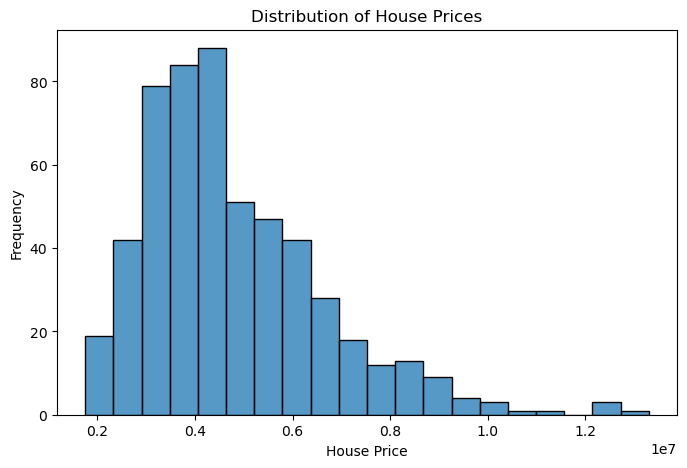

In [67]:
# Create a histogram showing the distribution of house prices.
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

# Caption:
# This histogram shows the distribution of house prices.
# Most houses are concentrated in the lower and middle price ranges, with fewer expensive houses.

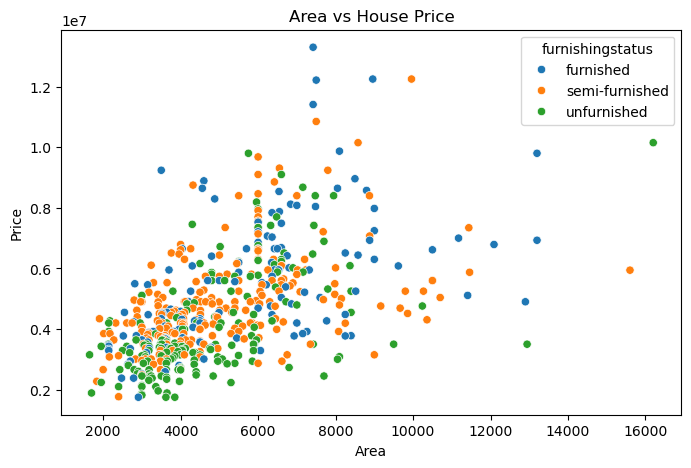

In [68]:
# Create a scatter plot showing the relationship between area and price.
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="area",
    y="price",
    hue="furnishingstatus"
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

# Caption:
# House prices generally increase as area increases.
# Furnishing status also appears to influence selling price.

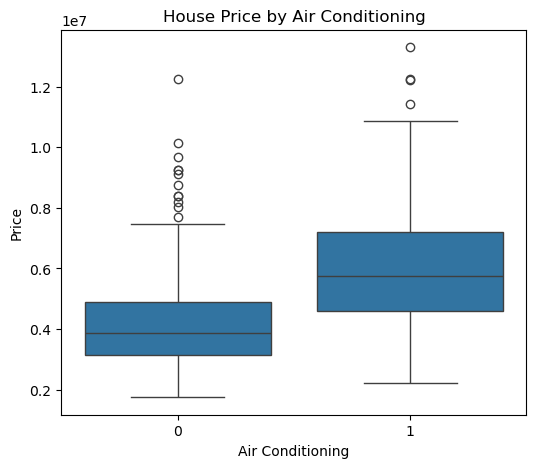

In [69]:
# Compare house prices based on air conditioning.
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="airconditioning",
    y="price"
)

plt.title("House Price by Air Conditioning")
plt.xlabel("Air Conditioning")
plt.ylabel("Price")

plt.show()

# Caption:
# Houses with air conditioning generally have higher prices.
# The box plot also highlights the spread of prices within each group.

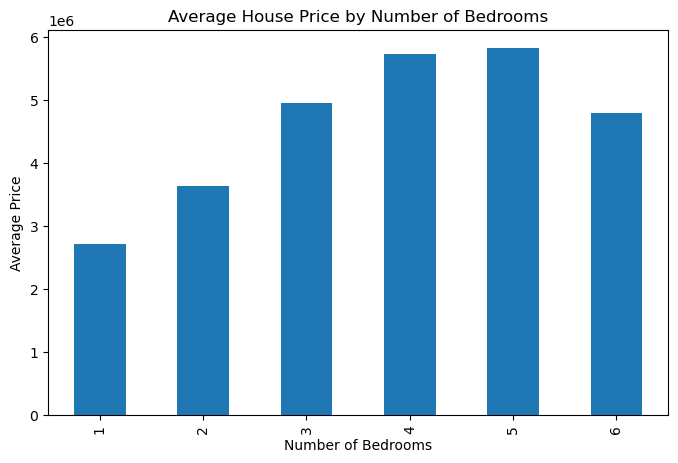

In [70]:
# Calculate the average house price by number of bedrooms.
average_price_bedrooms = df.groupby("bedrooms")["price"].mean()

# Create the bar chart.
plt.figure(figsize=(8,5))

average_price_bedrooms.plot(kind="bar")

plt.title("Average House Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")

plt.show()

# Caption:
# Houses with more bedrooms generally have higher average prices.
# Larger homes tend to command greater market value.

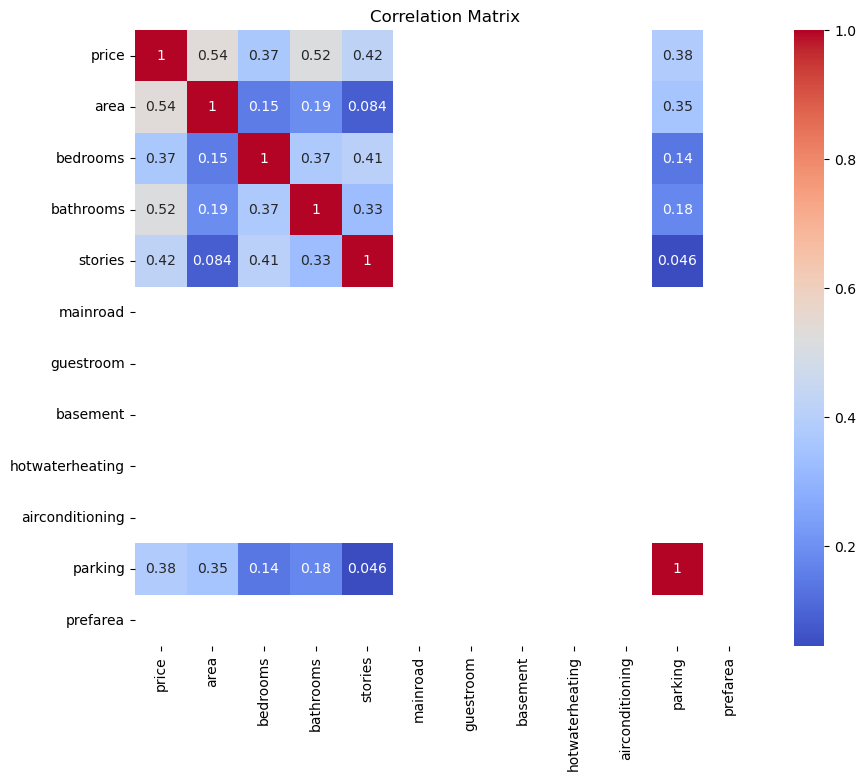

In [71]:
# Convert yes/no columns to 1/0 for correlation analysis.
correlation_df = df.copy()

yes_no_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for column in yes_no_columns:
    correlation_df[column] = correlation_df[column].map({"yes":1, "no":0})

# Create the correlation matrix.
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Caption:
# The heatmap shows relationships between all numeric variables.
# Darker colors indicate stronger positive or negative correlations.